#IMPORT LIBRARIES

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pickle

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer

import warnings
warnings.filterwarnings('ignore')

#LOAD DATA

In [10]:
try:
  df = pd.read_excel('/content/ecom customer_data.xlsx')
  print("Data loaded successfully")
  print(f"Shape: {df.shape}")
except FileNotFoundError:
  print("Error: File not found, Please upload 'ecom customer_data.xlsx' file")

Data loaded successfully
Shape: (30000, 38)


In [11]:
df.head()

,Cust_ID,Gender,Orders,Jordan,Gatorade,Samsung,Asus,Udis,Mondelez International,Wrangler,...,LG,Dior,Scabal,Tommy Hilfiger,Hollister,Forever 21,Colavita,Microsoft,Jiffy mix,Kraft
0,1,M,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,F,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,3,M,7,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,F,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,NaN,10,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Cust_ID                 30000 non-null  int64 
 1   Gender                  27276 non-null  object
 2   Orders                  30000 non-null  int64 
 3   Jordan                  30000 non-null  int64 
 4   Gatorade                30000 non-null  int64 
 5   Samsung                 30000 non-null  int64 
 6   Asus                    30000 non-null  int64 
 7   Udis                    30000 non-null  int64 
 8   Mondelez International  30000 non-null  int64 
 9   Wrangler                30000 non-null  int64 
 10  Vans                    30000 non-null  int64 
 11  Fila                    30000 non-null  int64 
 12  Brooks                  30000 non-null  int64 
 13  H&M                     30000 non-null  int64 
 14  Dairy Queen             30000 non-null  int64 
 15  Fe

In [13]:
df.describe()

,Cust_ID,Orders,Jordan,Gatorade,Samsung,Asus,Udis,Mondelez International,Wrangler,Vans,...,LG,Dior,Scabal,Tommy Hilfiger,Hollister,Forever 21,Colavita,Microsoft,Jiffy mix,Kraft
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,4.169800,0.267433,0.252333,0.222933,0.161333,0.143533,0.139767,0.106933,0.111433,...,0.102533,0.271133,0.370067,0.158967,0.077667,0.057333,0.192200,0.116367,0.088033,0.070900
std,8660.398374,3.590311,0.804778,0.705368,0.917494,0.740038,0.641258,0.525840,0.515921,0.547990,...,0.486376,0.714682,0.758465,0.510527,0.383370,0.300082,0.641306,0.446578,0.399277,0.387915
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15000.500000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,22500.250000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,30000.000000,12.000000,24.000000,15.000000,27.000000,17.000000,14.000000,31.000000,9.000000,16.000000,...,19.000000,12.000000,11.000000,8.000000,9.000000,8.000000,22.000000,14.000000,8.000000,16.000000


#DATA PREPROCESSING (THE DATA MODEL)

In [14]:
print("\n--- Starting Preprocessing ---")


--- Starting Preprocessing ---


Handle Missing Values

In [15]:
#filling gender NaN with mode
if "Gender" in df.columns:
  df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

Feature Selection & Encoding

In [16]:
#drop Cust_ID for training
X = df.drop(['Cust_ID'], axis=1)

In [17]:
#Encoder Gender: Male=1, Female=0
X['Gender'] = X['Gender'].map({'M': 1, 'F': 0})

In [18]:
#check for value missing
print("Missing values before fix:\n", X.isnull().sum().sum())

Missing values before fix:
 0


In [19]:
#fill the value
X = X.fillna(0)

In [20]:
#check value after fill
print("Missing values after fix:\n", X.isnull().sum().sum())

Missing values after fix:
 0


Standardization (Scaling)

In [23]:
# Crucial for K-Means to treat 'Orders' and 'Brands' equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("✅ Preprocessing Complete. Data Scaled.")

✅ Preprocessing Complete. Data Scaled.


In [25]:
missing_count = X_scaled_df.isnull().sum().sum()

if missing_count == 0:
    print("All Good! No missing values found. You can proceed to clustering.")
else:
    print(f"Still having issues. {missing_count} missing values found.")

All Good! No missing values found. You can proceed to clustering.


#FIND OPTIMAL CLUSTERS (Elbow Method)

In [26]:
print("\n--- Finding Optimal K ---")


--- Finding Optimal K ---


In [27]:
model = KMeans(random_state=42, n_init=10)

In [28]:
visualizer = KElbowVisualizer(model, k=(2, 11))

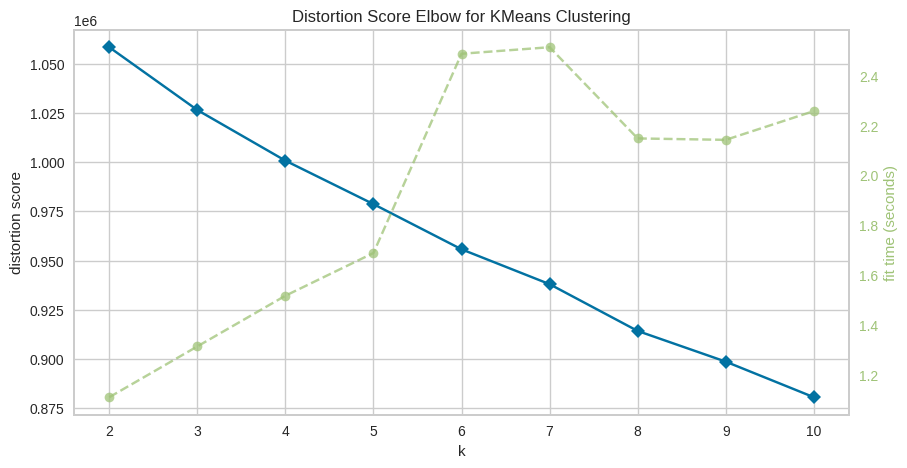

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [29]:
plt.figure(figsize=(10, 5))
visualizer.fit(X_scaled_df)
visualizer.show()

In [30]:
print(f"✅ Optimal K determined: {visualizer.elbow_value_}")

✅ Optimal K determined: None


#TRAIN THE MODEL

In [31]:
#using the optimal K found above (usually 3 or 4)
optimal_k = visualizer.elbow_value_ if visualizer.elbow_value_ else 3
print(f"\n--- Training Model with K={optimal_k} ---")


--- Training Model with K=3 ---


In [32]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [33]:
# Assign clusters back to original dataframe
df['Cluster_Label'] = clusters
print("✅ Clustering Complete. Labels assigned.")

✅ Clustering Complete. Labels assigned.


#VISUALIZATION (2D & 3D)

In [34]:
print("\n--- Generating Visualizations ---")


--- Generating Visualizations ---


In [35]:
#2D PCA Plot
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

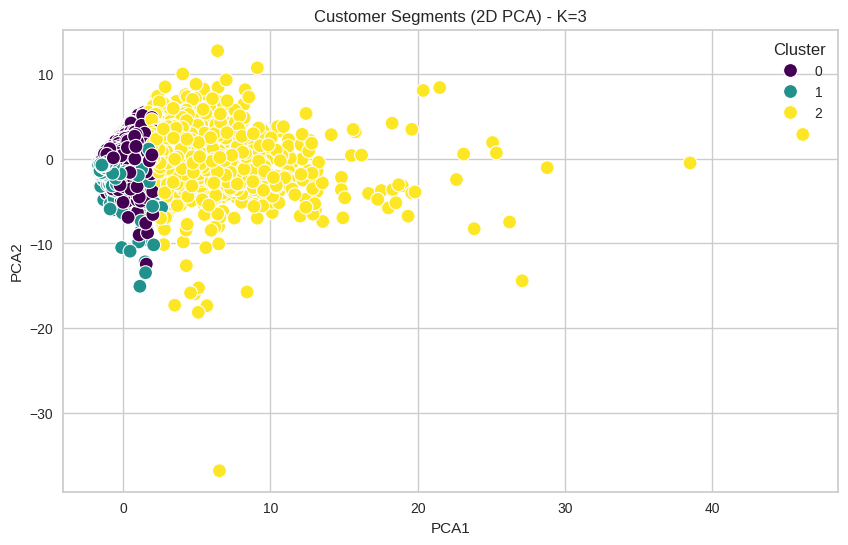

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', s=100)
plt.title(f'Customer Segments (2D PCA) - K={optimal_k}')
plt.show()

In [37]:
#Interactive 3D Plot (Plotly)
pca_3d = PCA(n_components=3)
pca_3d_data = pca_3d.fit_transform(X_scaled)
pca_3d_df = pd.DataFrame(pca_3d_data, columns=['PC1', 'PC2', 'PC3'])
pca_3d_df['Cluster'] = clusters.astype(str)

In [38]:
fig = px.scatter_3d(
    pca_3d_df, x='PC1', y='PC2', z='PC3', color='Cluster',
    title='Interactive 3D Customer Segments', opacity=0.8, size_max=10
)
fig.show()

In [39]:
print("\n--- Generating EDA Visualizations ---")


--- Generating EDA Visualizations ---


Histograms (Distribution of orders and genders)

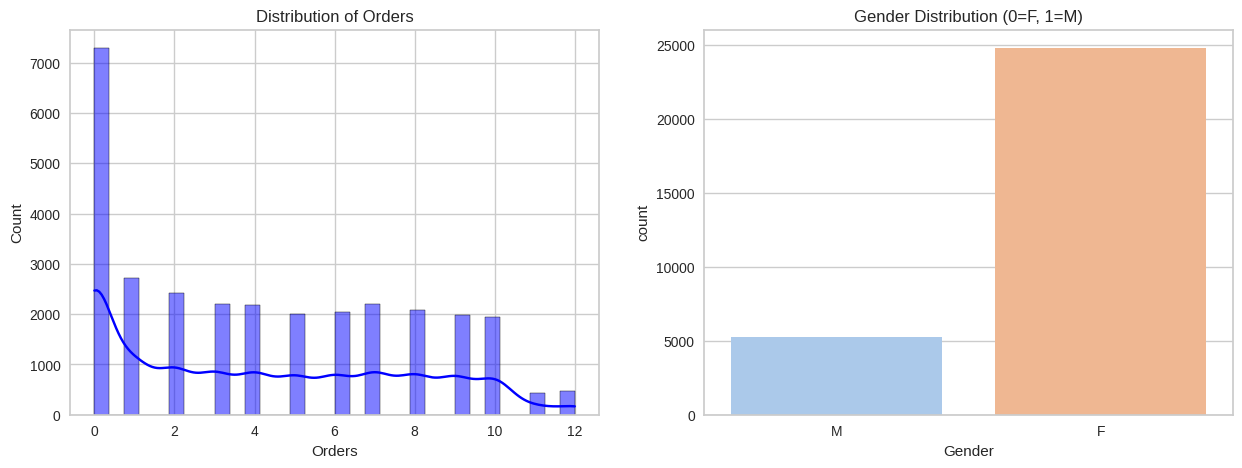

In [40]:
plt.figure(figsize=(15, 5))

# Plot Orders Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Orders'], kde=True, color='blue')
plt.title('Distribution of Orders')

# Plot Gender Distribution (if converted to 0/1, map back for label if needed or just plot)
plt.subplot(1, 2, 2)
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution (0=F, 1=M)')
plt.show()

Correlation Heatmap

In [41]:
# (Check relationships between top brands)
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

In [42]:
df_corr = df.copy()

In [44]:
if df_corr['Gender'].dtype == 'object':
   df_corr['Gender'] = df_corr['Gender'].map({'M': 1, 'F': 0})

In [45]:
#drop id for coorelation
corr_matrix = df_corr.drop(['Cust_ID', 'Cluster_Label'], axis=1, errors='ignore').corr()

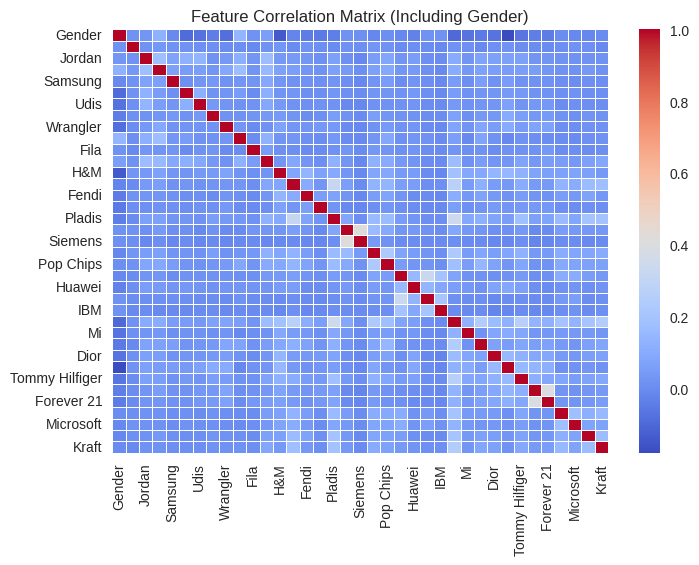

In [46]:
#Plot Heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5, annot=False)
plt.title('Feature Correlation Matrix (Including Gender)')
plt.show()

SILHOUETTE ANALYSIS FOR OPTIMAL K

In [47]:
print("\n--- Silhouette Score Analysis ---")


--- Silhouette Score Analysis ---


In [48]:
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    labels = km.labels_
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3968
K=3, Silhouette Score=0.0836
K=4, Silhouette Score=0.0826
K=5, Silhouette Score=0.0860
K=6, Silhouette Score=0.0830
K=7, Silhouette Score=0.0889
K=8, Silhouette Score=0.0881
K=9, Silhouette Score=0.0949
K=10, Silhouette Score=0.0922


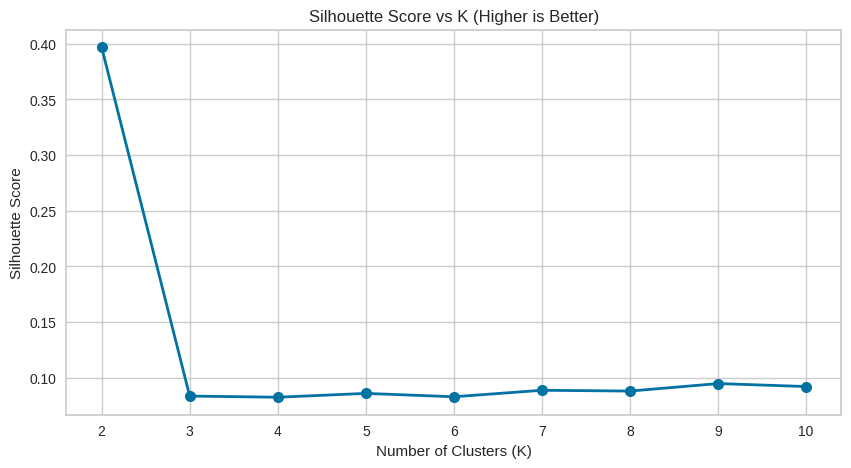

In [49]:
# Plotting the Silhouette Scores
plt.figure(figsize=(10, 5))
plt.plot(k_range, sil_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K (Higher is Better)')
plt.grid(True)
plt.show()


--- Silhouette Visualizer ---


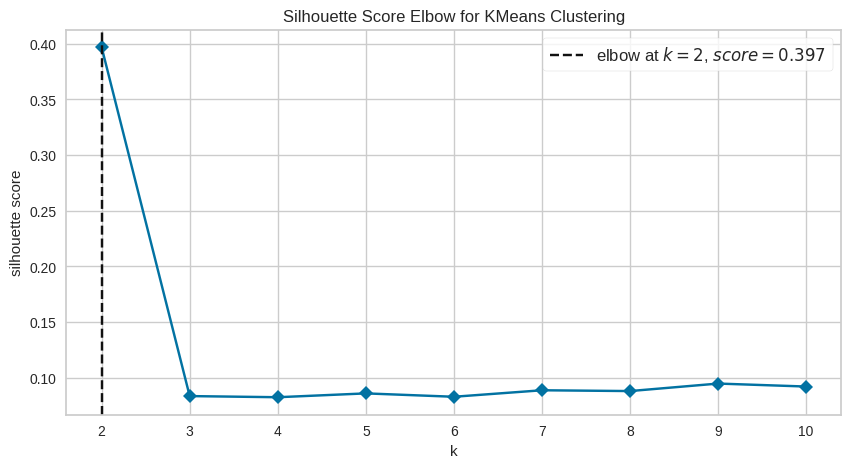

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [50]:
# Instantiate the clustering model and visualizer
print("\n--- Silhouette Visualizer ---")
model = KMeans(random_state=42, n_init=10)
# metric='silhouette' use karne se ye Silhouette score ka graph banayega
visualizer = KElbowVisualizer(model, k=(2, 11), metric='silhouette', timings=False)

plt.figure(figsize=(10, 5))
visualizer.fit(X_scaled)
visualizer.show()

In [51]:
# Calculate Silhouette Score for the chosen model
final_score = silhouette_score(X_scaled, clusters)
print(f"\n✅ Final Model (K={optimal_k}) Silhouette Score: {final_score:.4f}")


✅ Final Model (K=3) Silhouette Score: 0.0836


In [52]:
# Interpretation
if final_score > 0.5:
    print("Interpretation: Strong and dense clusters.")
elif final_score > 0.25:
    print("Interpretation: Reasonable clusters.")
else:
    print("Interpretation: Weak or overlapping clusters.")

Interpretation: Weak or overlapping clusters.


#CLUSTER PROFILING (Radar Charts)

In [53]:
print("\n--- Generating Cluster Profiles (Radar Charts) ---")


--- Generating Cluster Profiles (Radar Charts) ---


In [54]:
# Prepare data for Radar Chart (Scale to 0-1 for visibility)
df_profile = df.copy()

if df_profile['Gender'].dtype == 'object':
    df_profile['Gender'] = df_profile['Gender'].map({'M': 1, 'F': 0})

cluster_means = df_profile.drop(['Cust_ID'], axis=1).groupby('Cluster_Label').mean(numeric_only=True)


In [55]:
#Scaling (0-1 Range for Radar Chart)
scaler_minmax = MinMaxScaler()
cluster_means_scaled = pd.DataFrame(scaler_minmax.fit_transform(cluster_means), columns=cluster_means.columns, index=cluster_means.index)


In [56]:
#Radar Chart Function
def create_radar_chart(cluster_id):
    # Select top 10 features for this cluster
    top_features = cluster_means_scaled.loc[cluster_id].sort_values(ascending=False).head(10).index
    values = cluster_means_scaled.loc[cluster_id, top_features].values

    fig = go.Figure(data=go.Scatterpolar(
        r=values, theta=top_features, fill='toself', name=f'Cluster {cluster_id}'
    ))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        showlegend=False,
        title=f'Profile of Cluster {cluster_id} (Top 10 Interests)'
    )
    fig.show()

In [57]:
#Generate charts
for i in range(optimal_k):
    create_radar_chart(i)

#RECOMMENDATION ENGINE

In [58]:
print("\n--- Testing Recommendation Engine ---")


--- Testing Recommendation Engine ---


In [59]:
def recommend_products(cust_id, df, cluster_means, top_n=3):
    customer_data = df[df['Cust_ID'] == cust_id]
    if customer_data.empty: return "Customer not found"

    cluster_id = customer_data['Cluster_Label'].values[0]

    # Get top products for this cluster
    cluster_top_products = cluster_means.loc[cluster_id].sort_values(ascending=False).index

    recommendations = []
    for product in cluster_top_products:
        if product in ['Gender', 'Orders', 'Cluster_Label']: continue
        # Recommend if customer hasn't bought/searched it yet (low score)
        if customer_data[product].values[0] < 0.1:
            recommendations.append(product)
        if len(recommendations) >= top_n: break
    return recommendations

#TESTING THE MODEL

In [63]:
sample_id = df['Cust_ID'].iloc[50]

recs = recommend_products(sample_id, df, cluster_means)
print(f"Customer: {sample_id} | Segment: {df[df['Cust_ID']==sample_id]['Cluster_Label'].values[0]}")
print(f"Recommended Next Products: {recs}")

Customer: 51 | Segment: 0
Recommended Next Products: ['H&M', 'Burberry', 'Asics']


#SAVE MODEL

In [64]:
print("\n--- Saving Model for Production ---")


--- Saving Model for Production ---


In [65]:
model_data = {
    "model": kmeans,
    "scaler": scaler,
    "features": X.columns.tolist()
}
with open('customer_segmentation_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)
print("✅ Model saved as 'customer_segmentation_model.pkl'")

✅ Model saved as 'customer_segmentation_model.pkl'


In [66]:
from google.colab import files
files.download('customer_segmentation_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>